In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

sns.set_theme(style="whitegrid")

print("Libraries imported successfully")

Libraries imported successfully


In [74]:
df = pd.read_csv("ecommerce_sales.csv")

df.head()

,order_item_id,order_id,product_id,quantity,customer_id,order_date,total_amount,customer_name,email,city,product_name,category,price
0,1,1001,101,1,1,2026-01-10,58000.0,Arun Kumar,arun@gmail.com,Chennai,Laptop,Electronics,55000.0
1,2,1001,106,1,1,2026-01-10,58000.0,Arun Kumar,arun@gmail.com,Chennai,Mouse,Electronics,900.0
2,3,1002,102,1,2,2026-01-15,25000.0,Priya Sharma,priya@gmail.com,Coimbatore,Smartphone,Electronics,25000.0
3,4,1003,103,1,3,2026-02-05,3000.0,Rahul Singh,rahul@gmail.com,Bangalore,Headphones,Electronics,3000.0
4,5,1004,104,1,1,2026-02-20,8500.0,Arun Kumar,arun@gmail.com,Chennai,Office Chair,Furniture,8500.0


In [75]:
df.columns

Index(['order_item_id', 'order_id', 'product_id', 'quantity', 'customer_id',
       'order_date', 'total_amount', 'customer_name', 'email', 'city',
       'product_name', 'category', 'price'],
      dtype='object')

In [76]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 15
Number of columns: 13


In [77]:
df.shape

(15, 13)

## Dataset Overview

The ecommerce dataset contains transaction-level information including orders, customers, products, categories, quantities, prices, total amounts, cities, and order dates.

In [78]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   order_item_id  15 non-null     int64  
 1   order_id       15 non-null     int64  
 2   product_id     15 non-null     int64  
 3   quantity       15 non-null     int64  
 4   customer_id    15 non-null     int64  
 5   order_date     15 non-null     object 
 6   total_amount   15 non-null     float64
 7   customer_name  15 non-null     object 
 8   email          15 non-null     object 
 9   city           15 non-null     object 
 10  product_name   15 non-null     object 
 11  category       15 non-null     object 
 12  price          15 non-null     float64
dtypes: float64(2), int64(5), object(6)
memory usage: 1.7+ KB


### Observation

The `info()` function provides information about the structure of the dataset, including the number of records, columns, and data types.

In [79]:
df.describe()

,order_item_id,order_id,product_id,quantity,customer_id,total_amount,price
count,15.000000,15.000000,15.000000,15.0,15.000000,15.000000,15.000000
mean,8.000000,1005.666667,104.133333,1.0,3.266667,20953.333333,13793.333333
std,4.472136,3.039424,2.133631,0.0,1.869556,20436.342511,18593.181034
min,1.000000,1001.000000,101.000000,1.0,1.000000,3000.000000,900.000000
25%,4.500000,1003.500000,102.500000,1.0,2.000000,4300.000000,1350.000000
50%,8.000000,1006.000000,104.000000,1.0,3.000000,12900.000000,3000.000000
75%,11.500000,1008.000000,106.000000,1.0,4.500000,26800.000000,18500.000000
max,15.000000,1010.000000,107.000000,1.0,7.000000,58000.000000,55000.000000


### Observation

The descriptive statistics provide an overview of the numerical variables such as quantity, price, and total amount. These statistics help understand the central tendency and spread of the data.

In [80]:
df.isnull().sum()

,0
order_item_id,0
order_id,0
product_id,0
quantity,0
customer_id,0
order_date,0
total_amount,0
customer_name,0
email,0
city,0


In [81]:
df.isnull().sum().sum()

np.int64(0)

### Observation

The missing-value analysis was performed using `isnull().sum()`. The dataset contains no significant missing values, so no imputation was required.

In [82]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [83]:
df[df.duplicated()]

,order_item_id,order_id,product_id,quantity,customer_id,order_date,total_amount,customer_name,email,city,product_name,category,price


### Observation

Duplicate records were checked using the `duplicated()` function. Duplicate rows, if any, can affect the accuracy of statistical analysis and therefore need to be identified.

In [84]:
df.dtypes

,0
order_item_id,int64
order_id,int64
product_id,int64
quantity,int64
customer_id,int64
order_date,object
total_amount,float64
customer_name,object
email,object
city,object


In [85]:
df["order_date"] = pd.to_datetime(df["order_date"])

df.dtypes

,0
order_item_id,int64
order_id,int64
product_id,int64
quantity,int64
customer_id,int64
order_date,datetime64[ns]
total_amount,float64
customer_name,object
email,object
city,object


In [86]:
df["category"].value_counts()

,count
category,
Electronics,12
Furniture,3


In [87]:
df["city"].value_counts()

,count
city,
Chennai,5
Bangalore,4
Coimbatore,3
Madurai,2
Hyderabad,1


In [88]:
df["product_name"].value_counts()

,count
product_name,
Mouse,4
Headphones,3
Laptop,2
Smartphone,2
Table,2
Office Chair,1
Keyboard,1


## Value Count Analysis

Value counts were used to understand the frequency of different product categories, cities, and products in the ecommerce dataset.

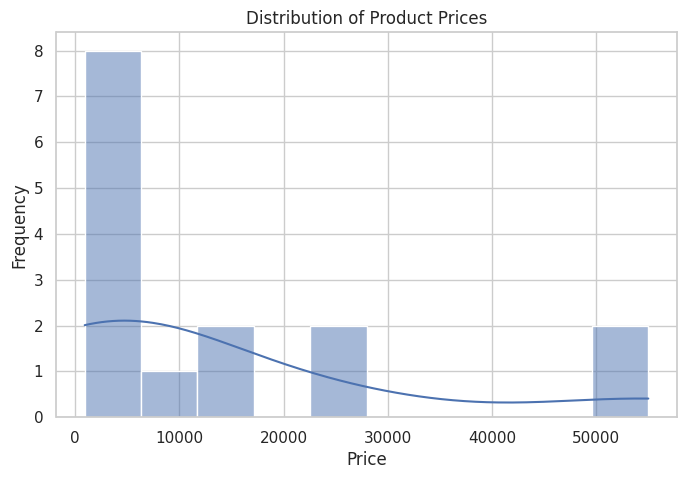

In [89]:
plt.figure(figsize=(8,5))

sns.histplot(df["price"], bins=10, kde=True)

plt.title("Distribution of Product Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.show()

### Observation

The histogram shows the distribution of product prices. It helps identify the most common price ranges and whether the prices are concentrated around particular values.

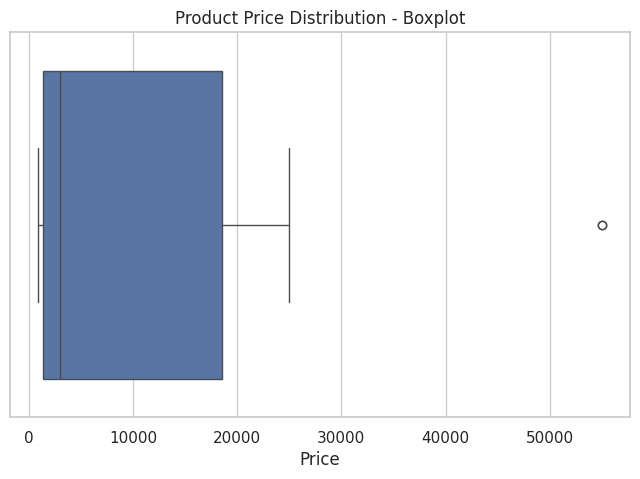

In [90]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df["price"])

plt.title("Product Price Distribution - Boxplot")
plt.xlabel("Price")

plt.show()

### Observation

The boxplot shows the median, spread, and potential outliers in product prices. Any points outside the whiskers may represent unusually high or low price values.

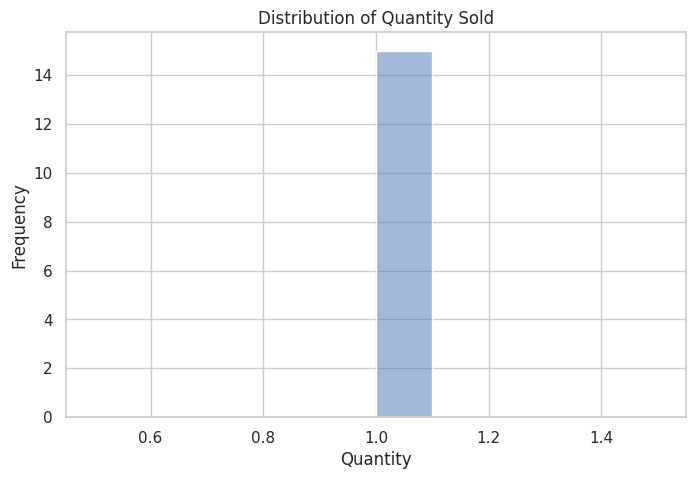

In [91]:
plt.figure(figsize=(8,5))

sns.histplot(df["quantity"], bins=10, kde=True)

plt.title("Distribution of Quantity Sold")
plt.xlabel("Quantity")
plt.ylabel("Frequency")

plt.show()

### Observation

The quantity distribution shows how many units are typically purchased in each transaction. This helps understand customer purchasing patterns.

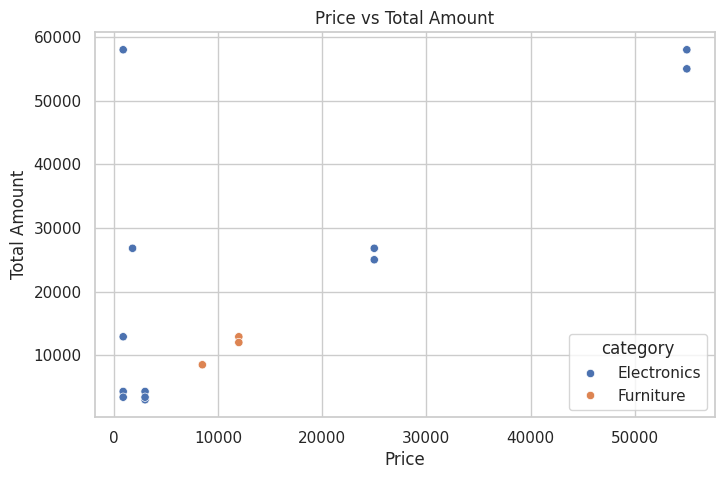

In [92]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="price",
    y="total_amount",
    hue="category"
)

plt.title("Price vs Total Amount")
plt.xlabel("Price")
plt.ylabel("Total Amount")

plt.show()

### Observation

The quantity distribution shows how many units are typically purchased in each transaction. This helps understand customer purchasing patterns.

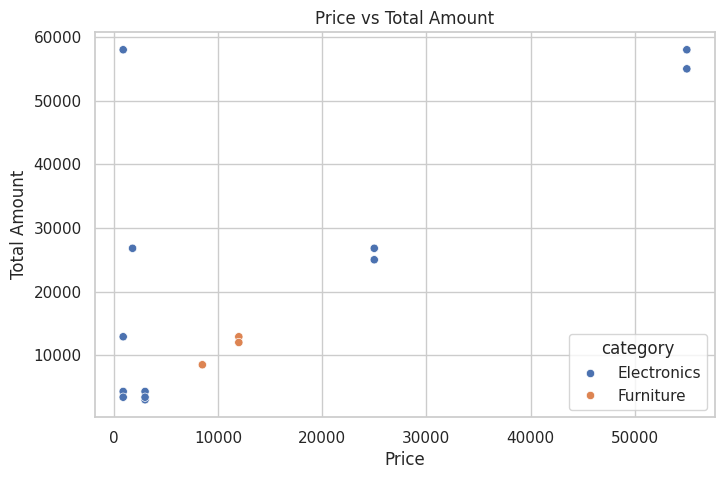

In [93]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="price",
    y="total_amount",
    hue="category"
)

plt.title("Price vs Total Amount")
plt.xlabel("Price")
plt.ylabel("Total Amount")

plt.show()

### Observation

The scatterplot shows the relationship between product price and total transaction amount. Higher quantities can cause the total amount to increase even when the individual product price remains unchanged.

In [94]:
category_sales = (
    df.groupby("category")["total_amount"]
    .sum()
    .sort_values(ascending=False)
)

category_sales

,total_amount
category,
Electronics,280900.0
Furniture,33400.0


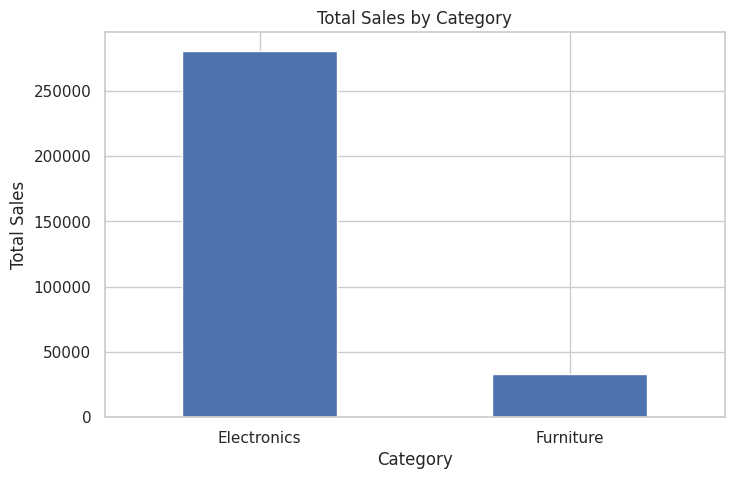

In [95]:
plt.figure(figsize=(8,5))

category_sales.plot(kind="bar")

plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")

plt.xticks(rotation=0)

plt.show()

### Observation

The category sales analysis shows the contribution of each product category to total revenue. The category with the highest value contributes the most to overall sales.

In [96]:
city_sales = (
    df.groupby("city")["total_amount"]
    .sum()
    .sort_values(ascending=False)
)

city_sales

,total_amount
city,
Chennai,178100.0
Bangalore,64800.0
Coimbatore,33600.0
Madurai,25800.0
Hyderabad,12000.0


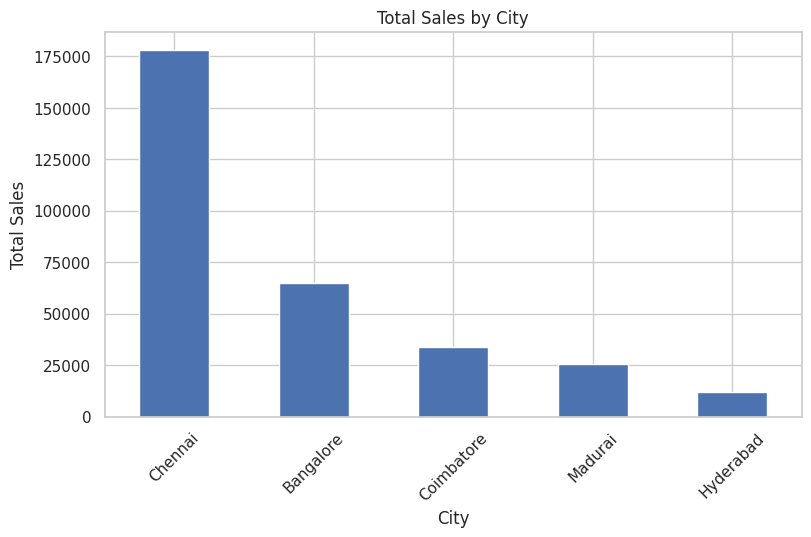

In [97]:
plt.figure(figsize=(9,5))

city_sales.plot(kind="bar")

plt.title("Total Sales by City")
plt.xlabel("City")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)

plt.show()

### Observation

The city-level analysis shows differences in sales contribution across locations. This can help identify cities with relatively stronger ecommerce sales performance.

In [98]:
df["month"] = df["order_date"].dt.to_period("M").astype(str)

df[["order_date", "month"]].head()

,order_date,month
0,2026-01-10,2026-01
1,2026-01-10,2026-01
2,2026-01-15,2026-01
3,2026-02-05,2026-02
4,2026-02-20,2026-02


In [99]:
monthly_sales = (
    df.groupby("month")["total_amount"]
    .sum()
)

monthly_sales

,total_amount
month,
2026-01,141000.0
2026-02,11500.0
2026-03,134400.0
2026-04,20600.0
2026-05,6800.0


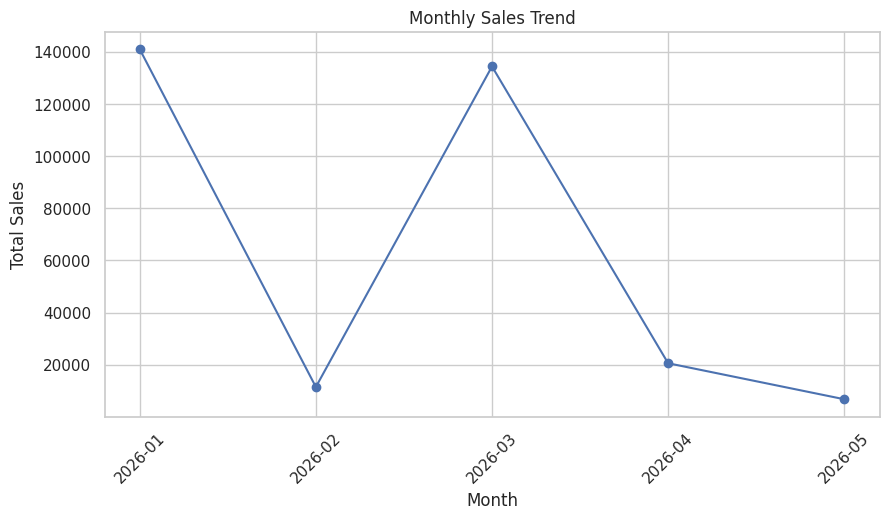

In [100]:
plt.figure(figsize=(10,5))

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)

plt.show()

### Observation

The monthly sales trend shows how total ecommerce sales change over time. Peaks represent periods of higher sales, while lower points represent periods of relatively lower sales.

In [101]:
numeric_df = df.select_dtypes(include=np.number)

correlation = numeric_df.corr()

correlation

,order_item_id,order_id,product_id,quantity,customer_id,total_amount,price
order_item_id,1.000000,0.993179,0.374290,NaN,0.469874,-0.578109,-0.340945
order_id,0.993179,1.000000,0.326761,NaN,0.481858,-0.597320,-0.314637
product_id,0.374290,0.326761,1.000000,NaN,0.259049,-0.387430,-0.694258
quantity,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_id,0.469874,0.481858,0.259049,NaN,1.000000,-0.090136,0.108345
total_amount,-0.578109,-0.597320,-0.387430,NaN,-0.090136,1.000000,0.694946
price,-0.340945,-0.314637,-0.694258,NaN,0.108345,0.694946,1.000000


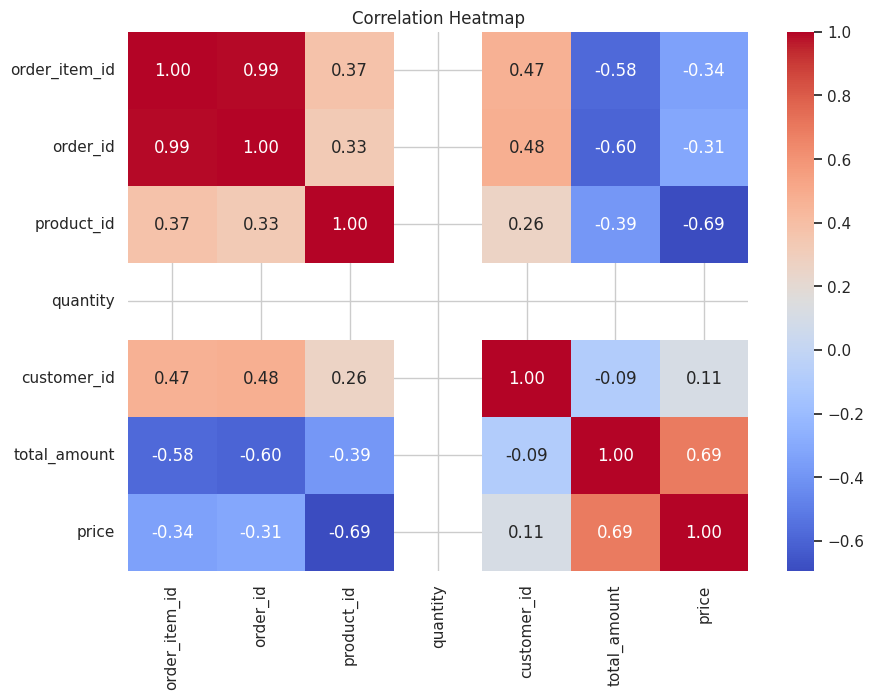

In [102]:
plt.figure(figsize=(10,7))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

### Observation

The correlation heatmap shows the strength and direction of relationships between numerical variables. Positive values indicate positive relationships, while negative values indicate negative relationships. Values close to zero indicate weak linear relationships.

In [103]:
product_sales = (
    df.groupby("product_name")["total_amount"]
    .sum()
    .sort_values(ascending=False)
)

product_sales

,total_amount
product_name,
Laptop,113000.0
Mouse,78600.0
Smartphone,51800.0
Keyboard,26800.0
Table,24900.0
Headphones,10700.0
Office Chair,8500.0


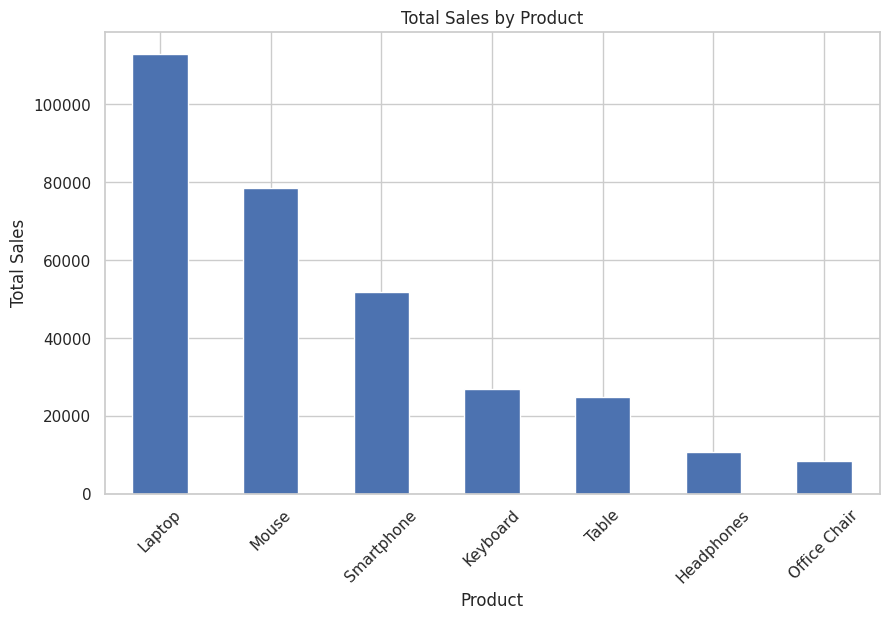

In [104]:
plt.figure(figsize=(10,6))

product_sales.plot(kind="bar")

plt.title("Total Sales by Product")
plt.xlabel("Product")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)

plt.show()

### Observation

The product-level analysis identifies the products that contribute the highest total sales. These products can be considered important contributors to ecommerce revenue.

In [105]:
customer_sales = (
    df.groupby("customer_name")["total_amount"]
    .sum()
    .sort_values(ascending=False)
)

customer_sales

,total_amount
customer_name,
Arun Kumar,124500.0
Sneha Patel,55000.0
Divya Raj,53600.0
Priya Sharma,33600.0
Karthik Kumar,25800.0
Vijay Anand,12000.0
Rahul Singh,9800.0


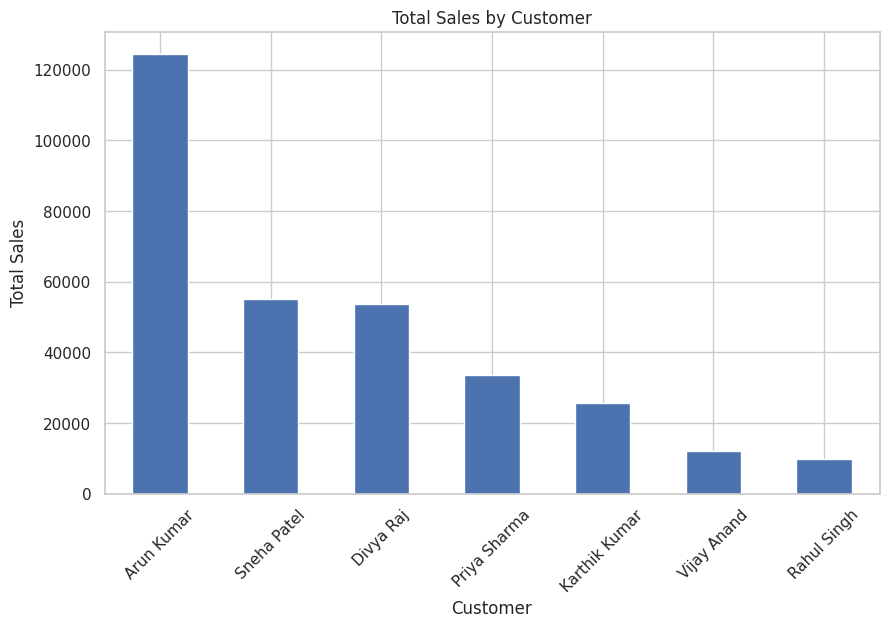

In [106]:
plt.figure(figsize=(10,6))

customer_sales.plot(kind="bar")

plt.title("Total Sales by Customer")
plt.xlabel("Customer")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)

plt.show()

### Observation

The customer-level analysis identifies customers with the highest total purchase value. This provides an overview of customer contribution to overall ecommerce sales.

In [107]:
df.nlargest(
    5,
    "total_amount"
)[[
    "order_id",
    "customer_name",
    "product_name",
    "quantity",
    "price",
    "total_amount"
]]

,order_id,customer_name,product_name,quantity,price,total_amount
0,1001,Arun Kumar,Laptop,1,55000.0,58000.0
1,1001,Arun Kumar,Mouse,1,900.0,58000.0
9,1007,Sneha Patel,Laptop,1,55000.0,55000.0
5,1005,Divya Raj,Smartphone,1,25000.0,26800.0
6,1005,Divya Raj,Keyboard,1,1800.0,26800.0


### Observation

The analysis identifies the five highest-value transactions. These transactions represent orders with relatively high total amounts and can be examined to understand high-value purchasing behavior.

# Final Summary and Findings

## Key Findings

1. The ecommerce dataset contains transaction, customer, product, category, location, and sales information.

2. Descriptive statistics were used to understand the numerical variables.

3. Missing values and duplicate records were checked to assess data quality.

4. Value-count analysis was used to identify frequently occurring categories, cities, and products.

5. The price histogram shows the distribution of product prices.

6. The boxplot helps identify the spread and potential outliers in product prices.

7. The scatterplot shows the relationship between product price and total transaction amount.

8. Category-level analysis helps identify the strongest contributors to overall sales.

9. City-level analysis shows differences in sales performance across locations.

10. Monthly sales analysis helps identify changes and trends over time.

11. The correlation heatmap shows relationships between numerical variables.

12. The pairplot provides a broader view of relationships and distributions among quantity, price, and total amount.

13. Product and customer analysis helps identify major contributors to ecommerce sales.

## Conclusion

Exploratory Data Analysis provided useful insights into the ecommerce dataset by combining statistical analysis and data visualization. The analysis helped identify sales patterns, customer behavior, product performance, relationships between numerical variables, and potential anomalies. These insights can support better business and sales decision-making.